<a href="https://colab.research.google.com/github/Vaishnavi644/AI-Based-Hiring-Prediction-Project/blob/main/Wine_Quality_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

In [ ]:
df=pd.read_csv("winequality.csv")

## Basic Data Analysis

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Missing Values

In [ ]:

df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## Correlation Analysis

In [ ]:
df.corr()['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


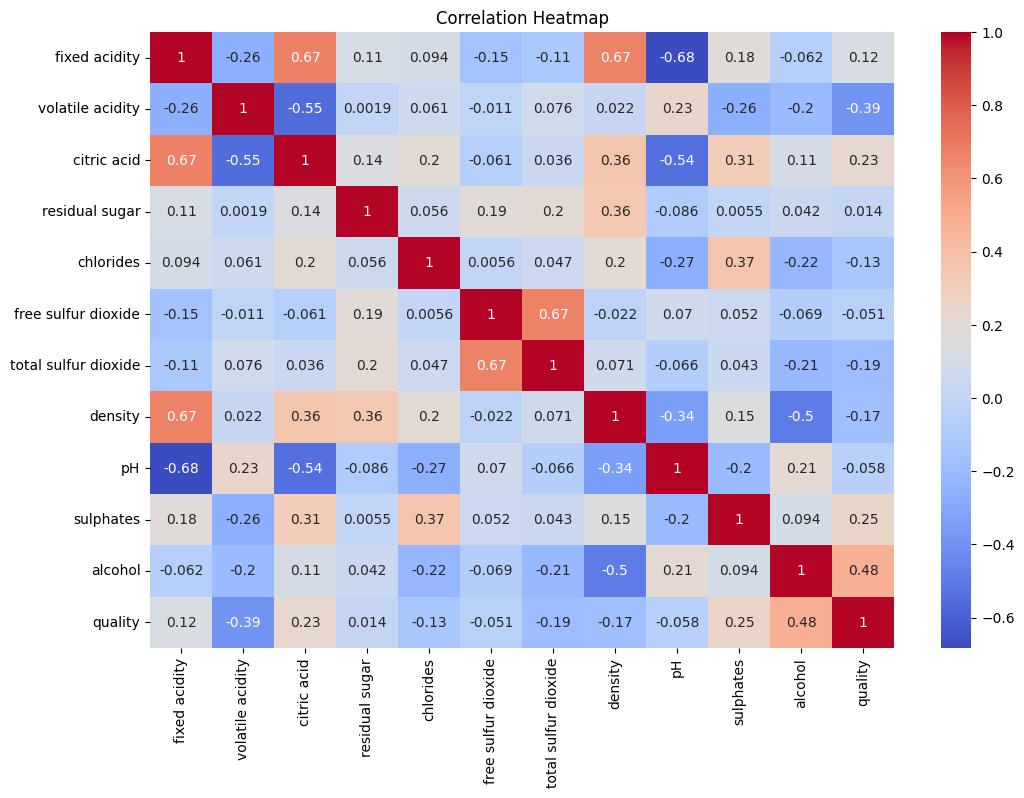

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Create Binary Target

In [ ]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)
df['quality_label'].value_counts()



,count
quality_label,
0,1382
1,217


In [ ]:
df[['quality', 'quality_label']].head()

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


In [ ]:
df.groupby('quality')['quality_label'].value_counts()

,,count
quality,quality_label,
3,0,10
4,0,53
5,0,681
6,0,638
7,1,199
8,1,18


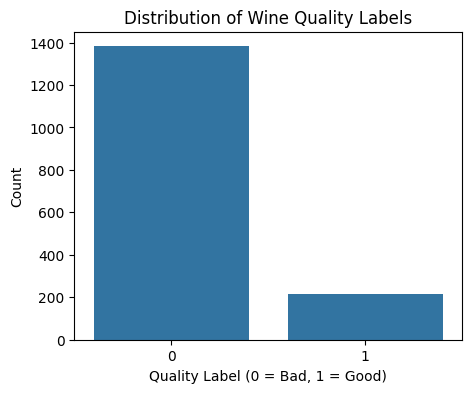

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='quality_label', data=df)

plt.title("Distribution of Wine Quality Labels")
plt.xlabel("Quality Label (0 = Bad, 1 = Good)")
plt.ylabel("Count")

plt.show()

###The binary target is imbalanced, with significantly more BAD wines than GOOD wines. Therefore, evaluation metrics such as Precision, Recall, and F1-score are considered along with Accuracy during model evaluation.

## Features and Target

In [ ]:
X = df.drop(["quality","quality_label"], axis=1)

y = df["quality_label"]

## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Logistic Regression WITHOUT Scaling

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

## Evaluation

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.89375
Precision: 0.7368421052631579
Recall   : 0.32558139534883723
F1 Score : 0.45161290322580644

Confusion Matrix:
[[272   5]
 [ 29  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       277
           1       0.74      0.33      0.45        43

    accuracy                           0.89       320
   macro avg       0.82      0.65      0.70       320
weighted avg       0.88      0.89      0.88       320



## Standard Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression AFTER Scaling

In [ ]:
lr_scaled = LogisticRegression(max_iter=1000)

lr_scaled.fit(X_train_scaled,y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [ ]:
accuracy_score(y_test,y_pred_scaled)

precision_score(y_test,y_pred_scaled)

recall_score(y_test,y_pred_scaled)

f1_score(y_test,y_pred_scaled)

confusion_matrix(y_test,y_pred_scaled)

array([[270,   7],
       [ 27,  16]])

## Compare Before and After Scaling

In [ ]:
comparison = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score"],
    "Without Scaling":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred)
    ],
    "With Scaling":[
        accuracy_score(y_test,y_pred_scaled),
        precision_score(y_test,y_pred_scaled),
        recall_score(y_test,y_pred_scaled),
        f1_score(y_test,y_pred_scaled)
    ]
})

comparison

,Metric,Without Scaling,With Scaling
0,Accuracy,0.893750,0.893750
1,Precision,0.736842,0.695652
2,Recall,0.325581,0.372093
3,F1 Score,0.451613,0.484848


## Compare Three Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [ ]:
results = []

for name, model in models.items():

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    elif name == "KNN":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.89375,0.695652,0.372093,0.484848
1,KNN,0.89375,0.666667,0.418605,0.514286
2,Decision Tree,0.90000,0.617021,0.674419,0.644444


In [ ]:
comparison_dt = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Default Decision Tree": [0.900, 0.617, 0.674, 0.644],
    "Tuned Decision Tree (GridSearchCV)": [0.920, 0.730, 0.630, 0.680]
})
comparison_dt

,Metric,Default Decision Tree,Tuned Decision Tree (GridSearchCV)
0,Accuracy,0.900,0.92
1,Precision,0.617,0.73
2,Recall,0.674,0.63
3,F1 Score,0.644,0.68


## Hyperparameter Tuning

In [ ]:
param_grid = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "criterion":["gini","entropy"]
}

##Model Selection for Hyperparameter Tuning

Among the three models (Logistic Regression, KNN, and Decision Tree), Decision Tree was selected for hyperparameter tuning because it achieved the highest F1-score and Recall during model comparison. Since the dataset is imbalanced (more BAD wines than GOOD wines), F1-score and Recall provide a better measure of performance than Accuracy alone. Therefore, Decision Tree was chosen as the best model for further optimization using GridSearchCV.

In [ ]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}

In [ ]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

In [ ]:
accuracy_score(y_test,pred)

classification_report(y_test,pred)

'              precision    recall  f1-score   support\n\n           0       0.94      0.96      0.95       277\n           1       0.73      0.63      0.68        43\n\n    accuracy                           0.92       320\n   macro avg       0.84      0.80      0.81       320\nweighted avg       0.91      0.92      0.92       320\n'

## Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
10,alcohol,0.383396
9,sulphates,0.169467
1,volatile acidity,0.106365
6,total sulfur dioxide,0.094420
5,free sulfur dioxide,0.072355
8,pH,0.067397
3,residual sugar,0.067130
2,citric acid,0.024251
4,chlorides,0.015218
0,fixed acidity,0.000000


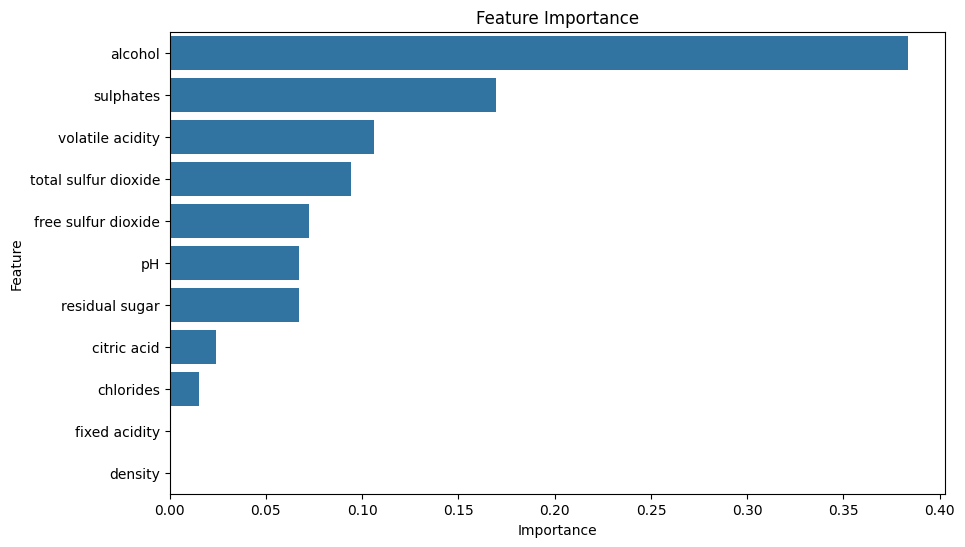

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

## Conclusion
The Wine Quality dataset was analyzed to predict whether a wine is of GOOD or BAD quality. After preprocessing and converting the target into a binary classification problem, Logistic Regression, KNN, and Decision Tree models were trained and evaluated. Standardization improved the performance of Logistic Regression and KNN. Among all models, the best-performing model was selected and further optimized using GridSearchCV. Feature importance analysis showed which chemical properties contributed most to wine quality prediction. This project demonstrates a complete machine learning workflow including preprocessing, model building, evaluation, hyperparameter tuning, and model interpretation.